# Plotting The CSVs created by the other Notebooks
most of these were initially plotted in `./demo_num_investigations.ipynb` however, it made it look messy and was hard to find what I needed, this is a more structured and I think overall better system to plot things

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product

## Helpers


In [3]:
def parse_list(ss: str):
  s = ss.strip("[]")
  # print(s)
  s = re.sub(r"\s+", " ", s)
  return np.fromstring(s, sep=" ")

def parse_list_bools(ss: str):
  s = ss.strip("[]")
  s = re.sub(r"\s+", " ", s)
  bools = s.split(" ")
  return np.array([b == 'True' for b in bools], dtype=bool)


## does not preserve the dimensionality of the tensor
def parse_1d_tensor(ss: str):
  s = re.sub(r"^tensor", "", ss)
  s = s.strip("()[]")
  return torch.tensor(np.fromstring(s, sep=", "), dtype=torch.float32)



### Cam Attention Helpers

In [4]:
def plot_cam_attention(df, task_name):
  fig, axs = plt.subplots(1, 2, figsize=(12, 6))

  pools = df["pool_method"].unique()

  for pi, pool in enumerate(pools):
    pool_df = df[df["pool_method"] == pool]

    sns.lineplot(ax=axs[pi], data=pool_df, x="demo_count", y="avg_final_dist", hue="cam_type", marker="o")
    axs[pi].set_title(f"'{task_name}' - Pooling method: '{pool}'")
    axs[pi].set_xlabel("Number of Demos")
    axs[pi].set_ylabel("Final Average Distance")
    axs[pi].legend(title="Cam Type")
    
  fig.text(0.2, -0.1, "See `plots.ipynb > Cam Attention checks with differnet cameras - 1st Time` for the parameters used")
  plt.show()

def plot_cam_attention_heatmap(df, fix_tensors = True):
  if fix_tensors:
    df["avg_avg_attn_above"] = df["avg_avg_attn_above"].apply(parse_1d_tensor)
    df["avg_avg_attn_below"] = df["avg_avg_attn_below"].apply(parse_1d_tensor)
  
  cam_combos = df["cam_type"].unique()
  pools = df["pool_method"].unique()
  demo_counts = df["demo_count"].unique()

  num_cams = len(cam_combos)
  num_pools = len(pools)

  for di, demo_count in enumerate(demo_counts):
    ## make a new plot for each demo count, easier to digest
    fig, axs = plt.subplots(num_cams, num_pools, figsize=(16, 10))
    for ci, cam_type in enumerate(cam_combos):
      for pi, pool in enumerate(pools):
        ax = axs[ci, pi]
        
        pool_df = df[
          (df["pool_method"] == pool) &
          (df["cam_type"] == cam_type) &
          (df["demo_count"] == demo_count)
        ]
        
        x_labels = cam_type.split("+")
        
        if pool_df.empty:
          continue
        tensor_above = pool_df["avg_avg_attn_above"].values[0]
        tensor_below = pool_df["avg_avg_attn_below"].values[0]
        
        y_labels = ["Above", "Below"]
        stack = torch.stack([tensor_above, tensor_below], dim=0)
        sns.heatmap(ax=ax, data=stack.reshape(2, -1), cbar=True, cmap="YlGnBu", annot=True)
        
        ax.set_xticklabels(x_labels)
        ax.set_yticklabels(y_labels)
        ax.set_title(f"{cam_type} - {pool} - {demo_count} Demo{"s" if demo_count != 1 else ""}")
    fig.suptitle(f"Attention Maps for {demo_count} Demo{"s" if demo_count != 1 else ""}, Above and Below the Obstacle", fontsize=16)
    plt.tight_layout()
    plt.show()
  

SyntaxError: f-string: expecting '}' (4116977324.py, line 56)

# No Obstacle


## Different Camera Combinations, Single Cams



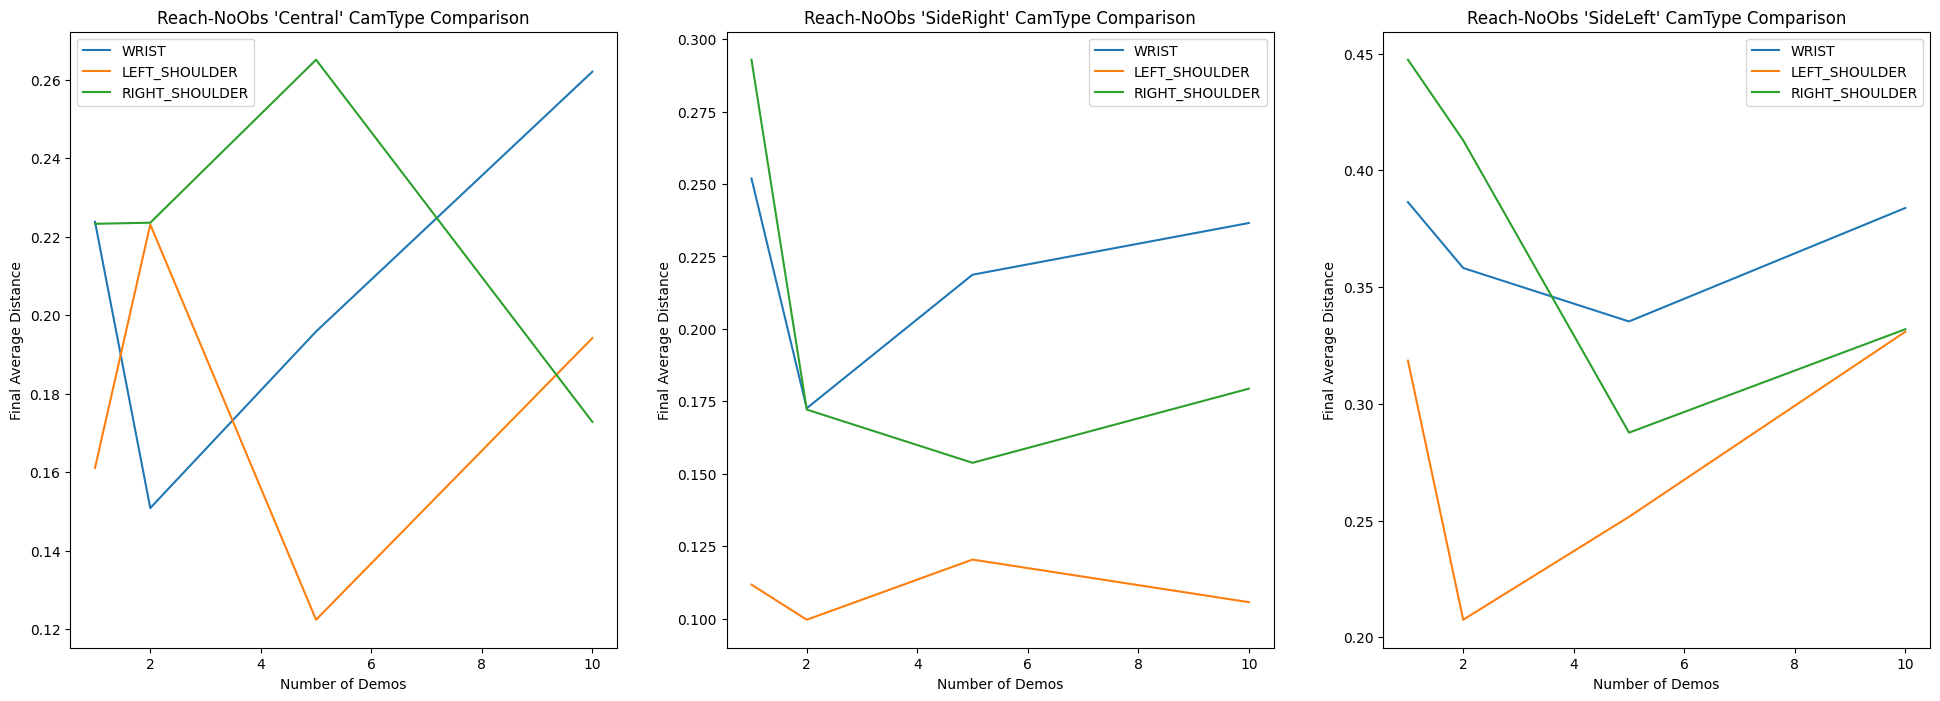

In [ ]:
df = pd.read_csv("run-csvs/reach-no-obs/diff_cams-results.csv")

tasks = df["task"].unique()
fig, ax = plt.subplots(1, len(tasks), figsize=(24, 8))

for ti, task in enumerate(tasks):
  task_df = df[df["task"] == task]
  
  for cam_type in task_df["cam_type"].unique():
    row_df = task_df[task_df["cam_type"] == cam_type]
    ax[ti].plot(row_df["demo_count"], row_df["final_dist"], label=cam_type)
    
  ax[ti].set_title(f"Reach-NoObs '{task}' CamType Comparison")
  ax[ti].set_xlabel("Number of Demos")
  ax[ti].set_ylabel("Final Average Distance")
  ax[ti].legend()



## Random Place - Different Cam Results

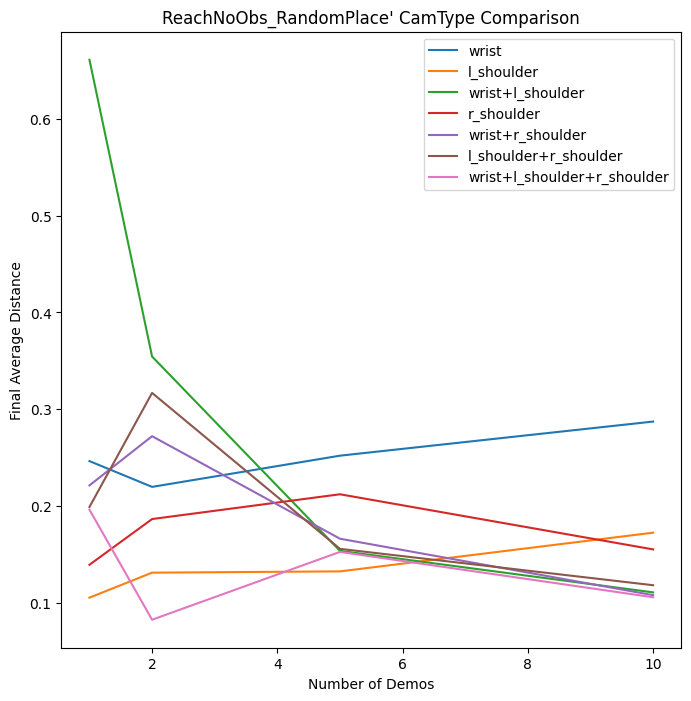

In [74]:
df = pd.read_csv("run-csvs/reach-no-obs/random_place-multicam-results.csv")
df["cam_type"] = df["cam_type"].apply(lambda x: re.sub(r"^\+", "", x))
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.lineplot(data=df, x="demo_count", y="final_dist", hue="cam_type", ax=ax)
  
ax.set_title(f"ReachNoObs_RandomPlace' CamType Comparison")
ax.set_xlabel("Number of Demos")
ax.set_ylabel("Final Average Distance")
ax.legend()



## `Reach_PlaceRandom` Epoch Trials
trying 1000 and 500 epochs to see which one is better at Beheaviourally Cloning this task


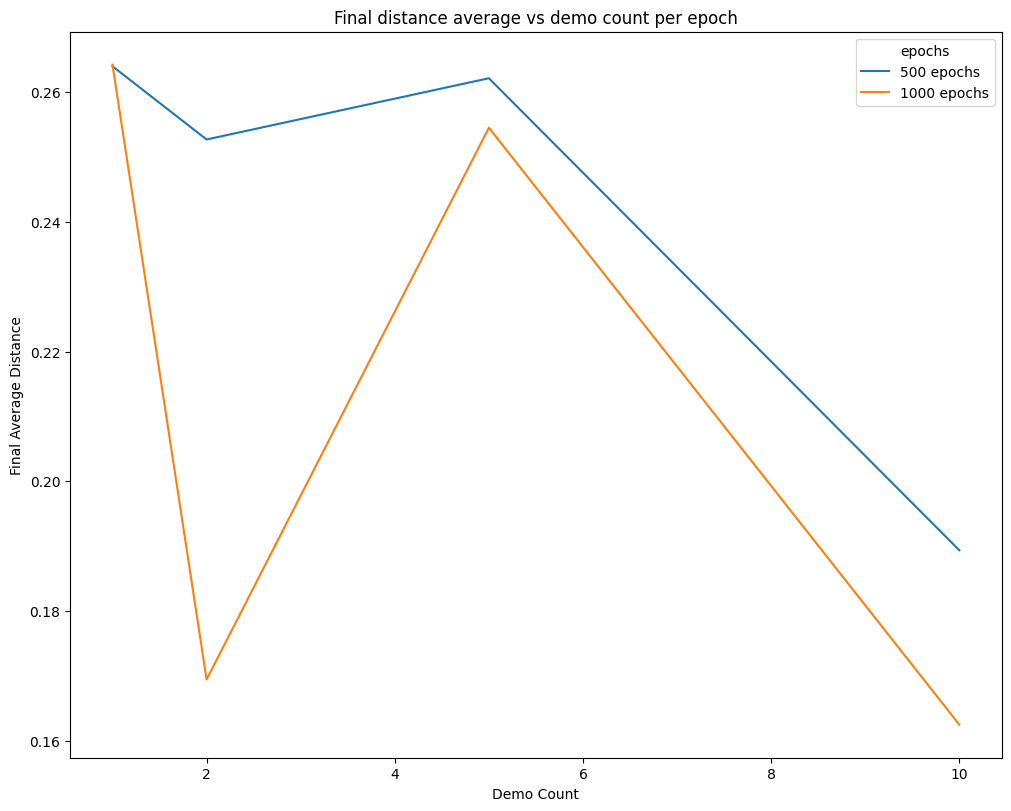

In [31]:
figsize = 10, 8
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)

## load the data df

df500 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-500epochs.csv")
df500["epoch"] = 500
df1000 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-1000epochs.csv")
df1000["epoch"] = 1000


ax.plot(df500["demo_count"], df500["final_dist_avg"], label = "500 epochs")
ax.plot(df1000["demo_count"], df1000["final_dist_avg"], label = "1000 epochs")

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")


# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

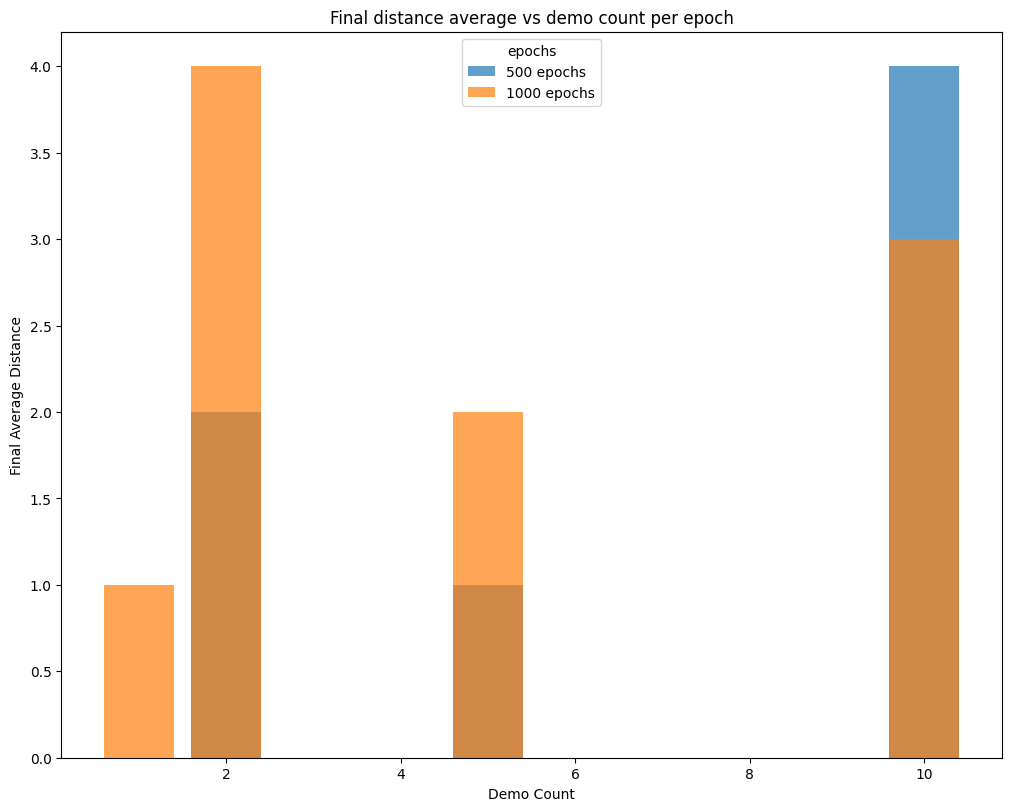

In [32]:
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)
ax.bar(df500["demo_count"], df500["reached_count"], label = "500 epochs", alpha = 0.7)
ax.bar(df1000["demo_count"], df1000["reached_count"], label = "1000 epochs", alpha = 0.7)

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")
plt.show()

# Reach With Obstacle


## Using the Same Unchanhed Policy from NoObs
Will not be looking at the reached counts, at this point there was no way of checking within err `within_err` in `run_task`, and this did not perform well anyway

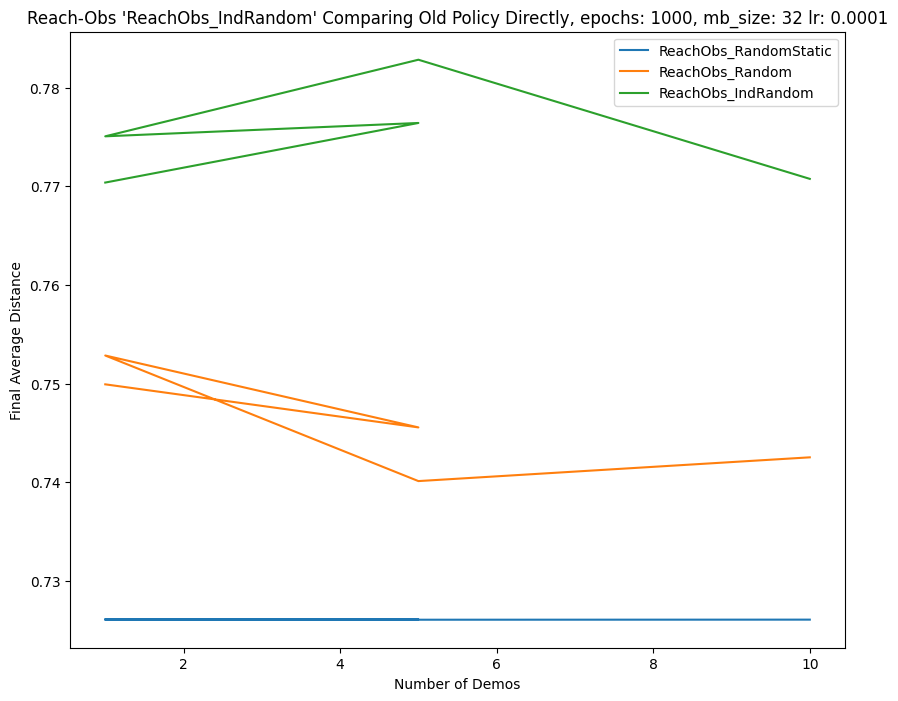

In [41]:
df = pd.read_csv("run-csvs/reach-obs/policy-improvement-resutls.csv")
df

epoch = 1000
mb = 32
lr = 0.0001
tasks = df["task_name"].unique()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for task in tasks:
  task_df = df[df["task_name"] == task]
  ax.plot(task_df["demo_count"], task_df["final_dist_avg"], label=task)
  
    
  ax.set_title(f"Reach-Obs '{task}' Comparing Old Policy Directly, epochs: {epoch}, mb_size: {mb} lr: {lr}")
  ax.set_xlabel("Number of Demos")
  ax.set_ylabel("Final Average Distance")
  ax.legend()
plt.show()

## Checking Policy Imrovements
done on task: `ReachObs_Random`

The main checks are more training and more demos

tried:
```python
demos = [5, 10, 15, 20]
{
  "epochs": [500, 1000]
  "mb_size": 64, 
  "lr": 0.01 ## newer systems are using cosiune annealing!
}
```
still not bery good, not consistently reaching need to find a better strategy to teach


In [57]:
df500 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-500-001-64.csv")
df1000 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-1000-001-64.csv")

df500["reached_count"] = df500["has_reached"].apply(lambda row: parse_list_bools(row).sum())
df1000["reached_count"] = df1000["has_reached"].apply(lambda row: parse_list_bools(row).sum())



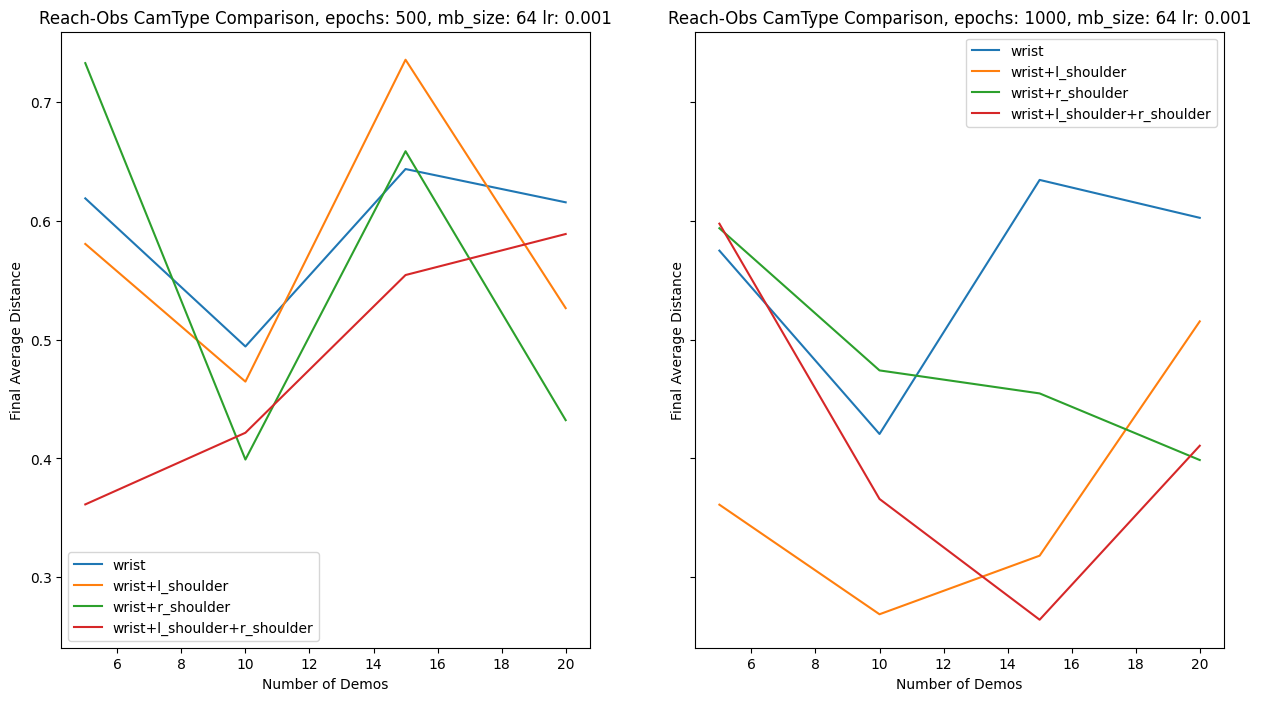

In [ ]:
figsize = 15, 8
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

cam_types = df500["cam_type"].unique()
dfs = [df500, df1000]
epochs = [500, 1000]
mb = 64
lr = 0.001

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    row_df = df[df["cam_type"] == cam_type]
    ax[di].plot(row_df["demo_count"], row_df["final_dist_avg"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
plt.show()

# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

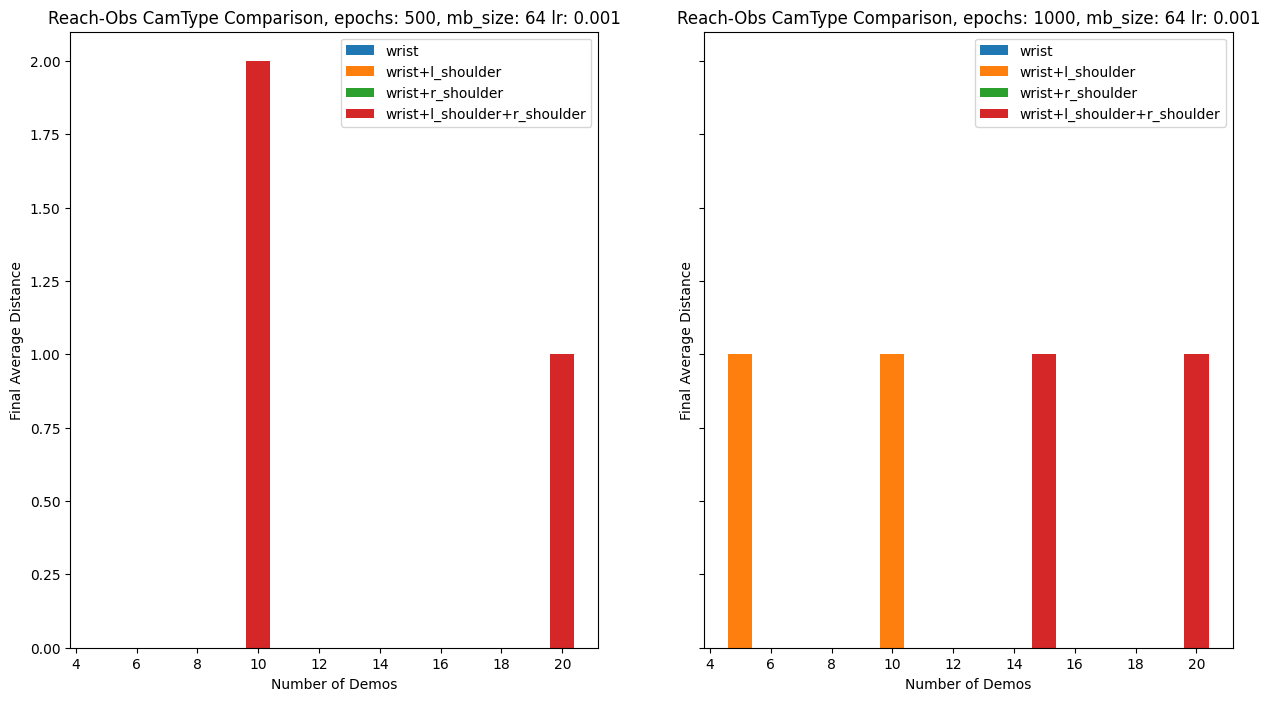

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    row_df = df[df["cam_type"] == cam_type]
    ax[di].bar(row_df["demo_count"], row_df["reached_count"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
  
plt.show()

## Checking Policy Improvements - Training Dataset Randomisation and Sampling
None of them are particularly good, there needs to be a different mechanism to check whether the randomisation is useful 

shuffling data works well, while ingesting, this will inherently shuffle the obs as well I think, so there is not reason to use `shuffle_obs_in_demo` really

In [9]:
df = pd.read_csv("run-csvs/reach-obs/2-5-10-shuffling-checks-reachobs_random.csv")
task_name  = "ReachObs_Random"
bool_combs = product([True, False], repeat=2)

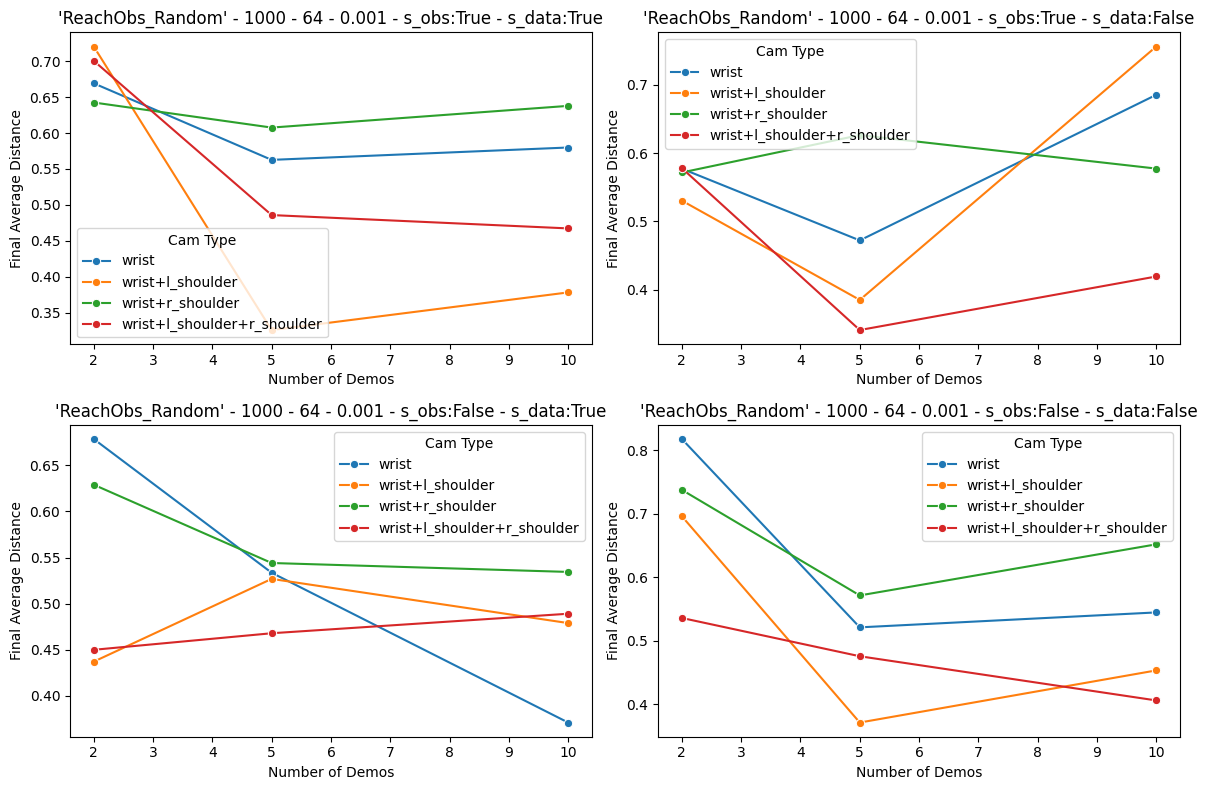

In [10]:


fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.lineplot(ax=axes[i], data=opts_df, x="demo_count", y="final_dist_avg", hue="cam_type", marker="o")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Final Average Distance")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


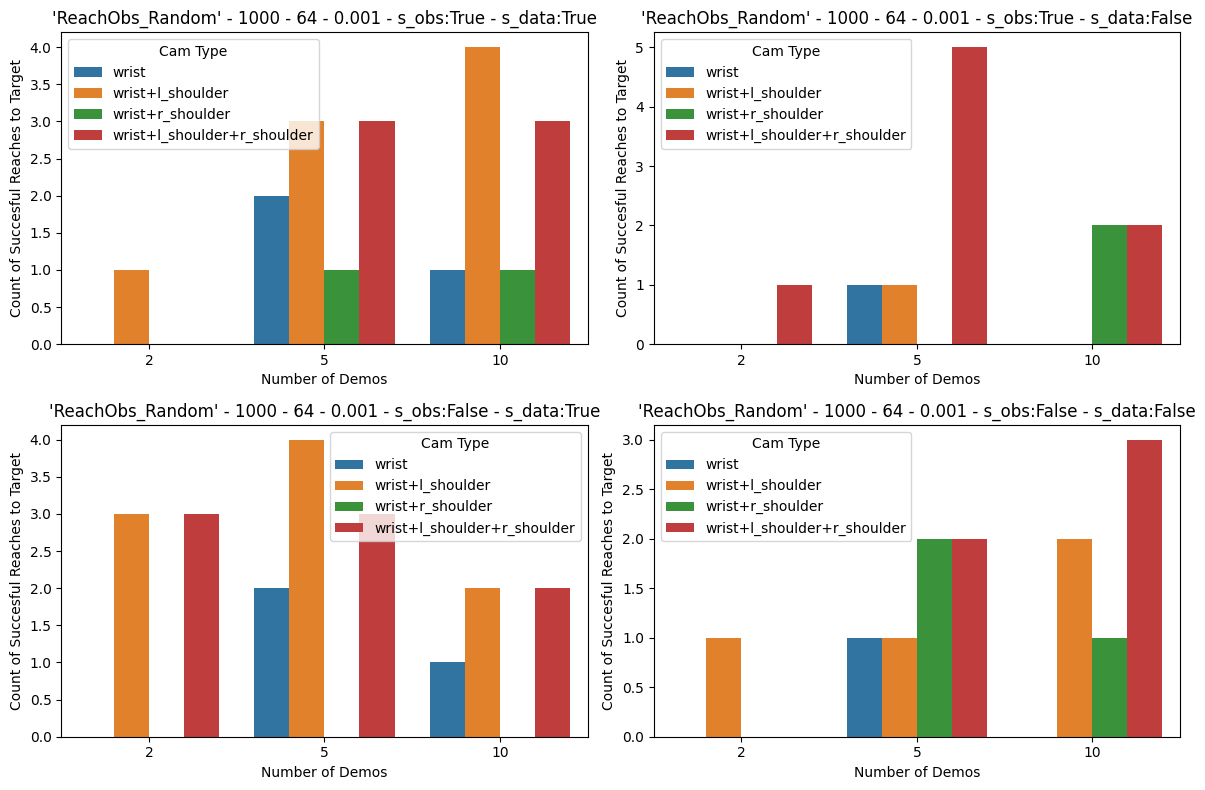

In [15]:

bool_combs = product([True, False], repeat=2)

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.barplot(ax=axes[i], data=opts_df, x="demo_count", y="reached_count", hue="cam_type")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Count of Succesful Reaches to Target")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


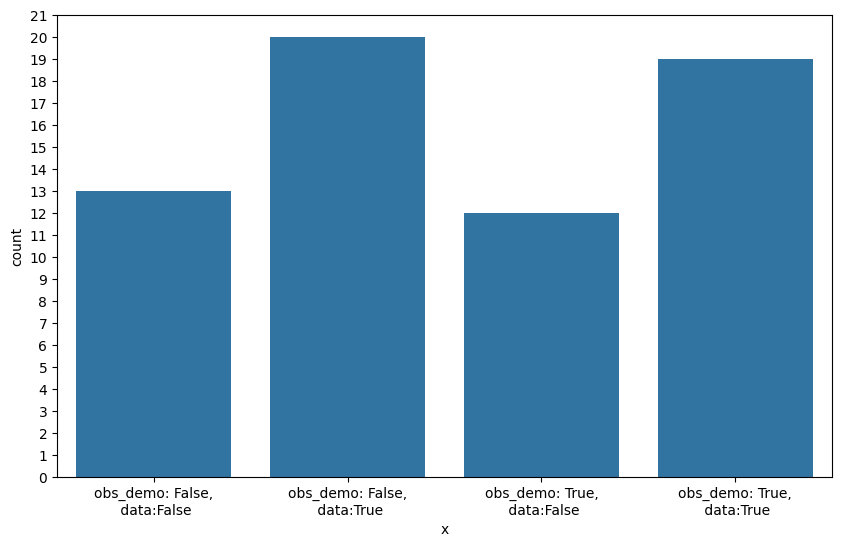

,shuffle_obs_in_demo,shuffle_data,count,x
0,False,False,13,"obs_demo: False,\n data:False"
1,False,True,20,"obs_demo: False,\n data:True"
2,True,False,12,"obs_demo: True,\n data:False"
3,True,True,19,"obs_demo: True,\n data:True"


In [18]:

grouped = df.groupby(["shuffle_obs_in_demo", "shuffle_data"])["reached_count"].apply("sum").reset_index(name = "count")
## name nicely
grouped["x"] = grouped.apply(
  lambda row: f"obs_demo: {row["shuffle_obs_in_demo"]},\n data:{row["shuffle_data"]}", axis=1
)


fig = plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, y="count", x="x")
# plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.show()
grouped


## Cam Attention checks with different cameras - 1st Time

These were trained with both the shuffling data settings turned to `False`, might have to run another time with the `shuffle_data` turned on?

```python
## params used
params = {
  "epochs": 1000,
  "minibatch_size": 64,
  "lr": 1e-3,
  "lr_eta_min": 1e-4,
  "shuffle_obs_in_demo": False, 
  "shuffle_data": False, 
  "lambda_attn": 1e-2,
}
```

Pooling method refers to the detection method used for the `colour_score()` method, 'mean' currently adds an epsilon of $1 \times 10^2$ to normalise, there might need to be more normalisation


### Multi-CNN Cam Attention
This network has a cnn feature extractor per camera
this works well to learn the interaction between the `colour_score` and the attention layer and helps extract important information per camera view.
However, a potential downside the `attention_score` and `action_score` terms in the **loss** might shave to be better tuned, chage their weightings for better results

In [88]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-multicnn.csv")

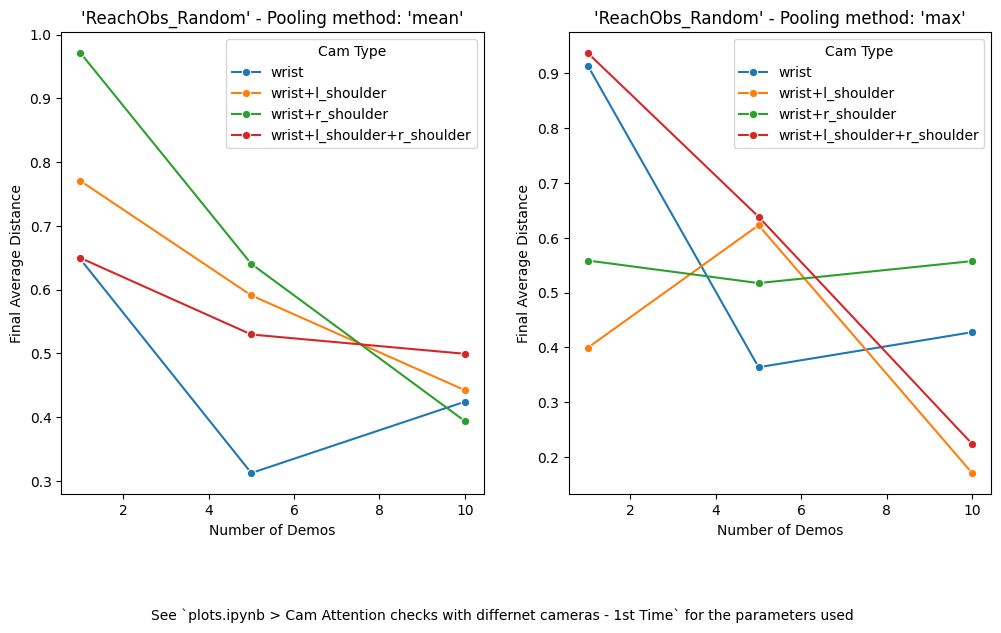

In [ ]:
plot_cam_attention(df, "ReachObs_Random")

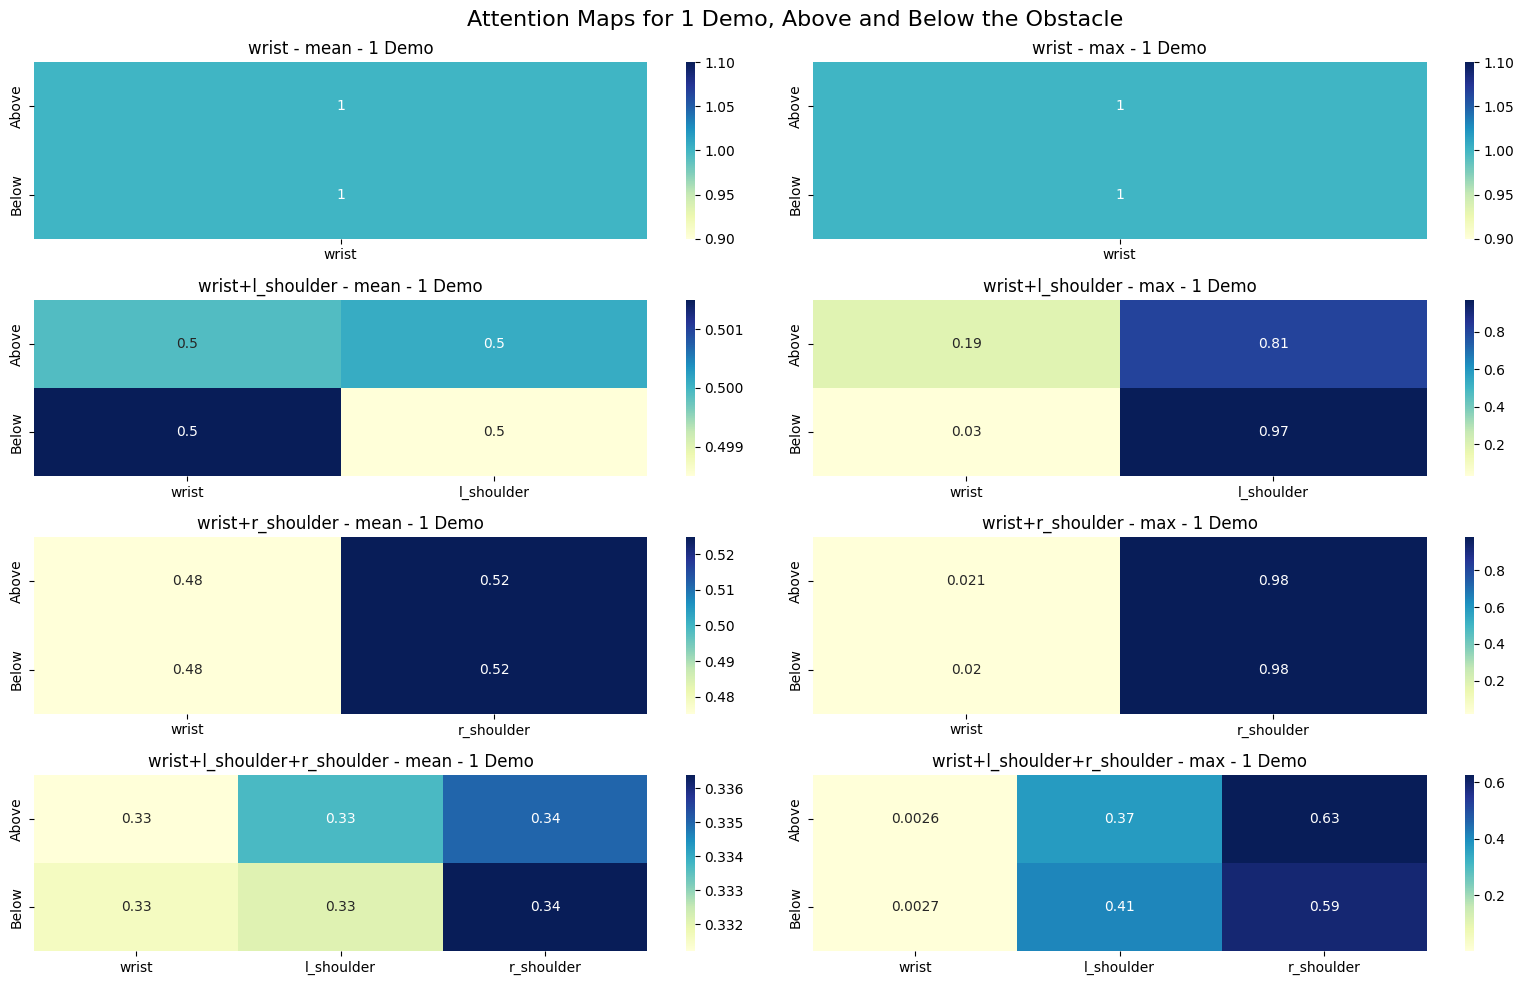

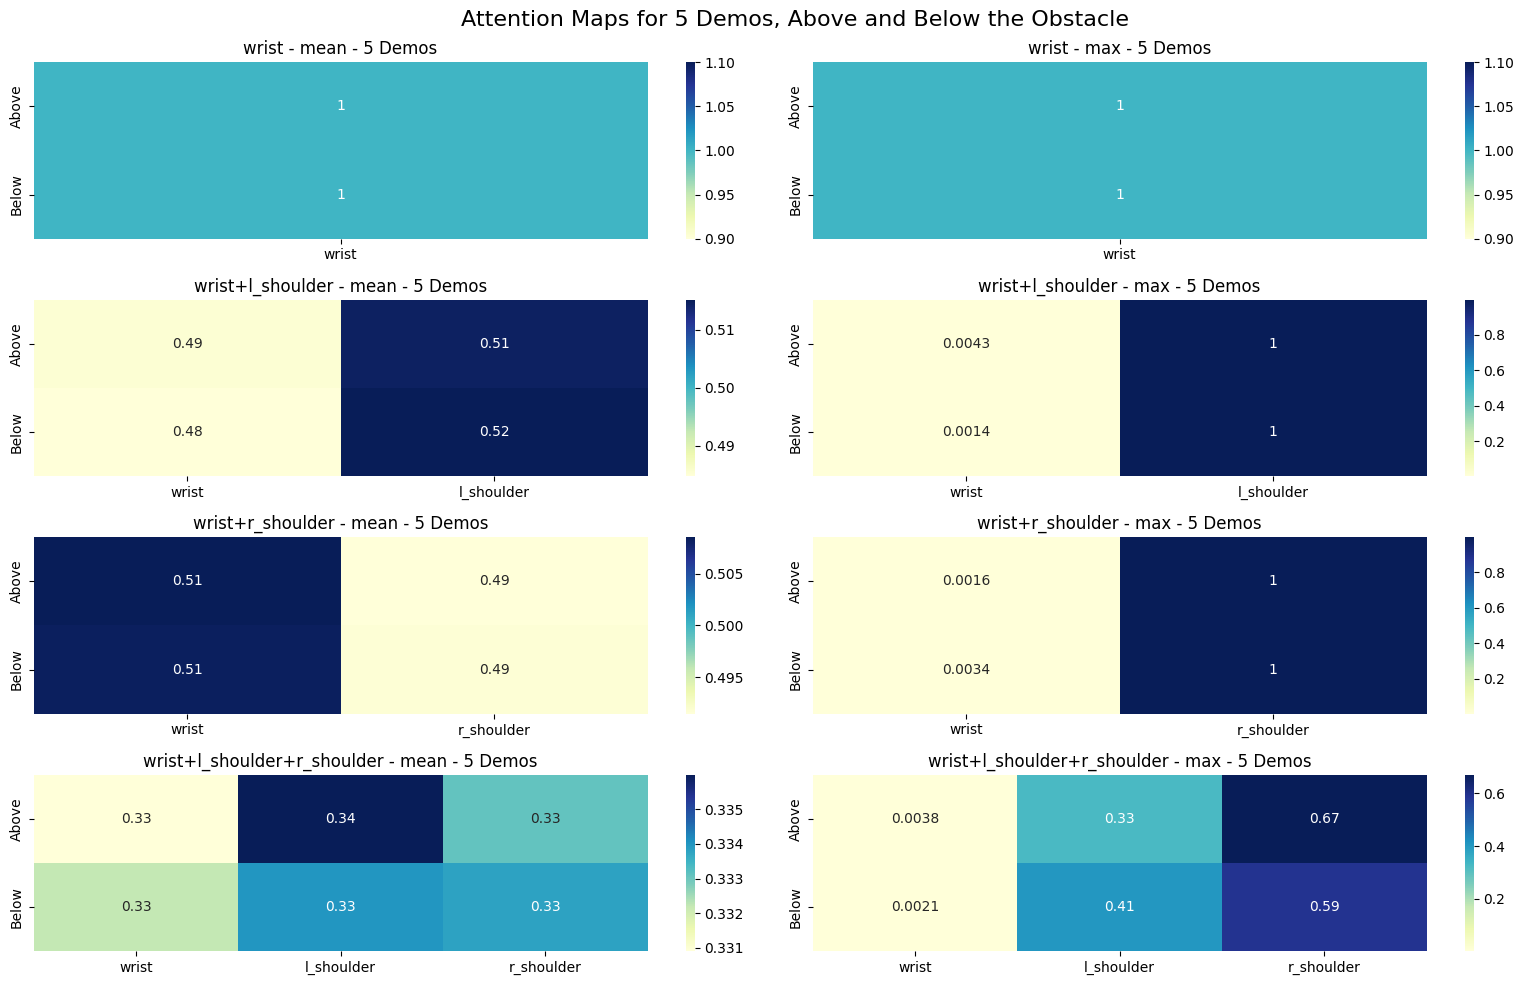

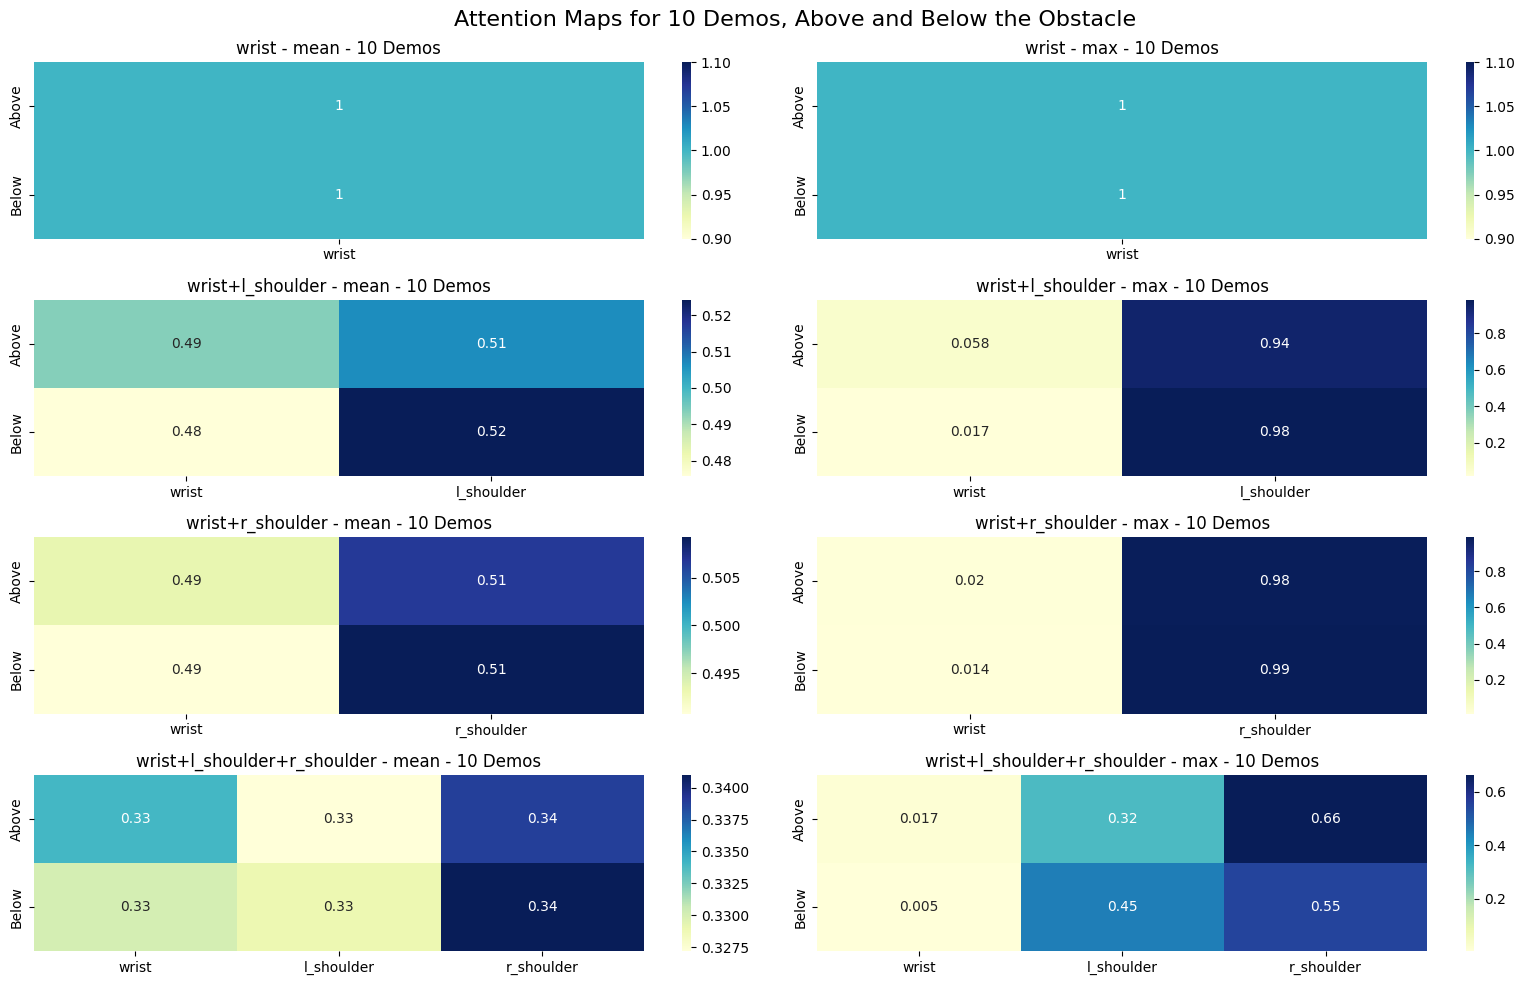

In [ ]:
plot_cam_attention_heatmap(df, fix_tensors=True)

### Single-CNN Cam Attention
This one, as the name suggests, is a single feature extractor from each camera, so the extractor should learn to extract similar features per camera. In theory I thought this would allow the inforamtion about the target, especially colour as I mainly use `colour_score` currently, to be extracted regardless of camera view.



In [92]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-singlecnn.csv")

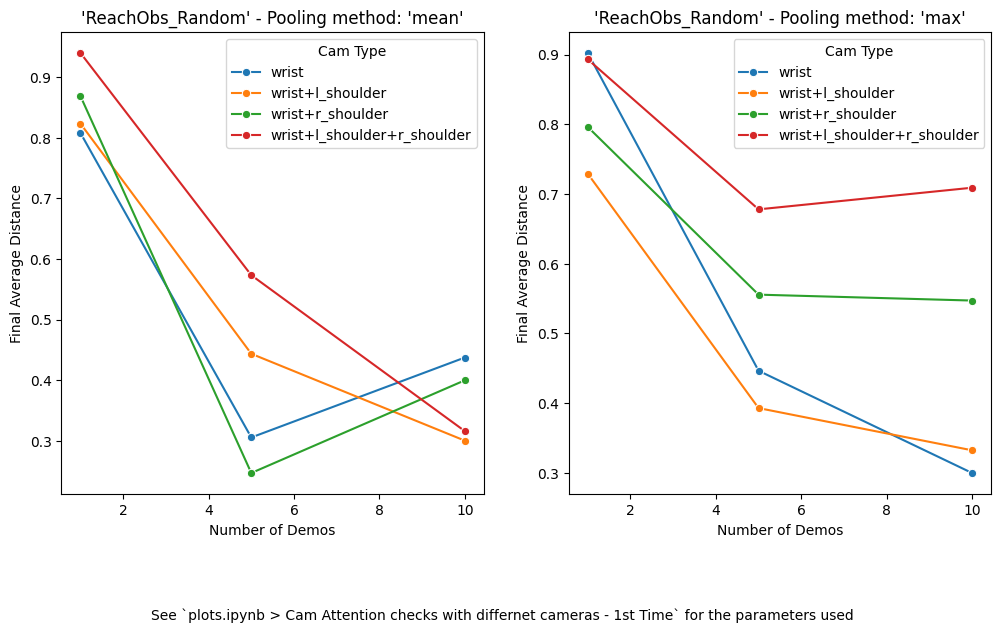

In [93]:
plot_cam_attention(df, "ReachObs_Random")

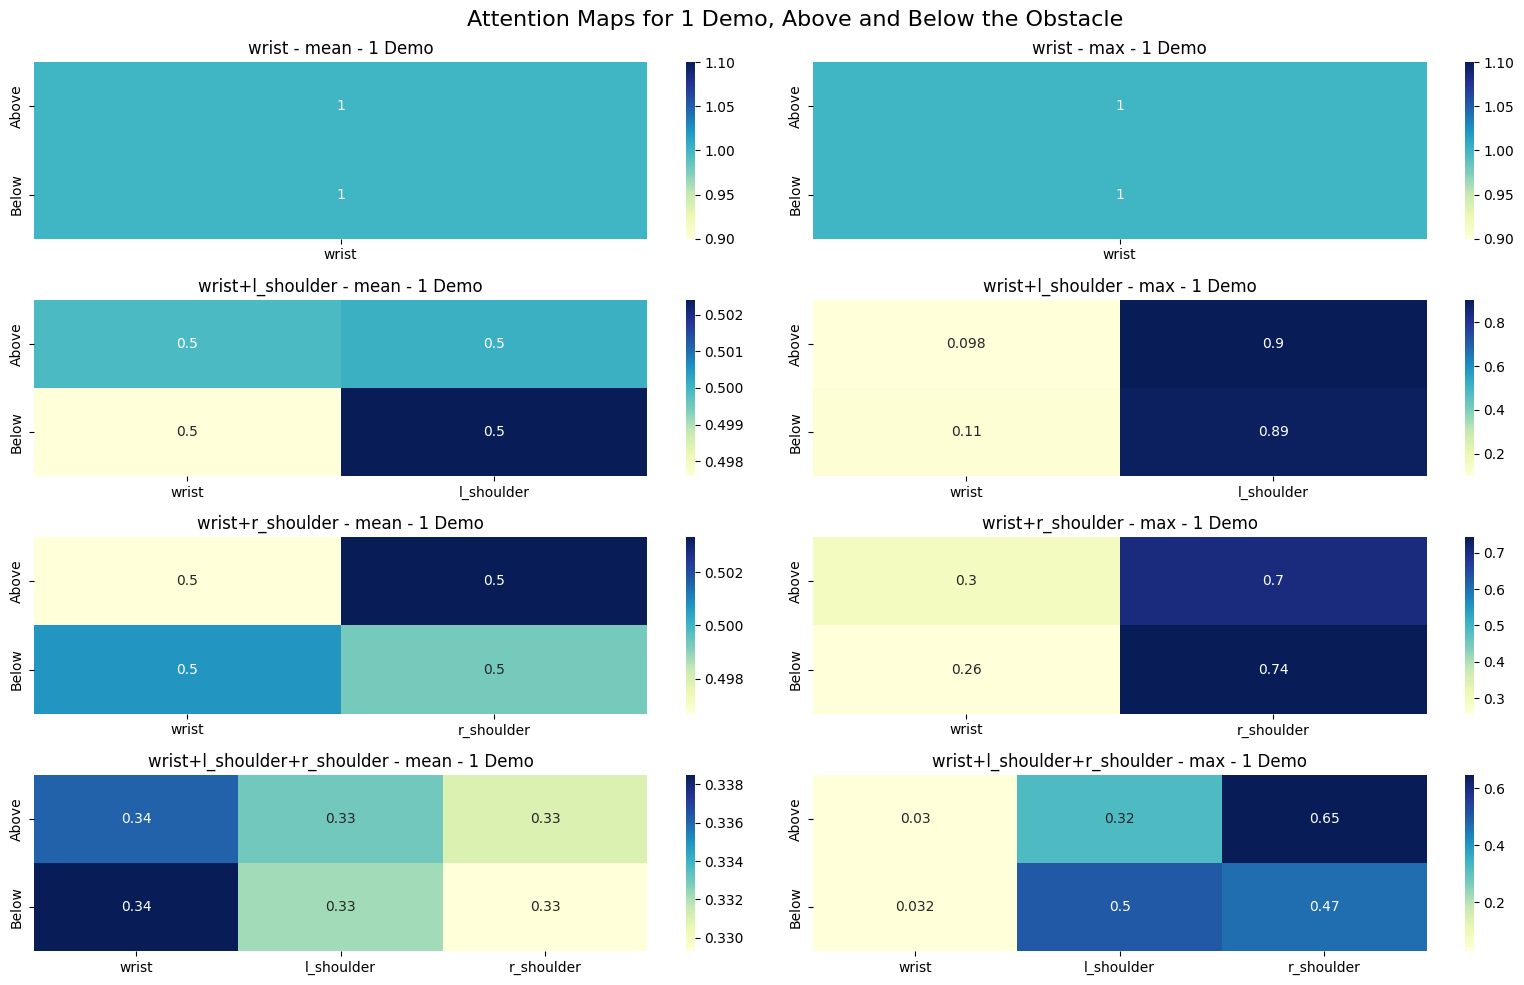

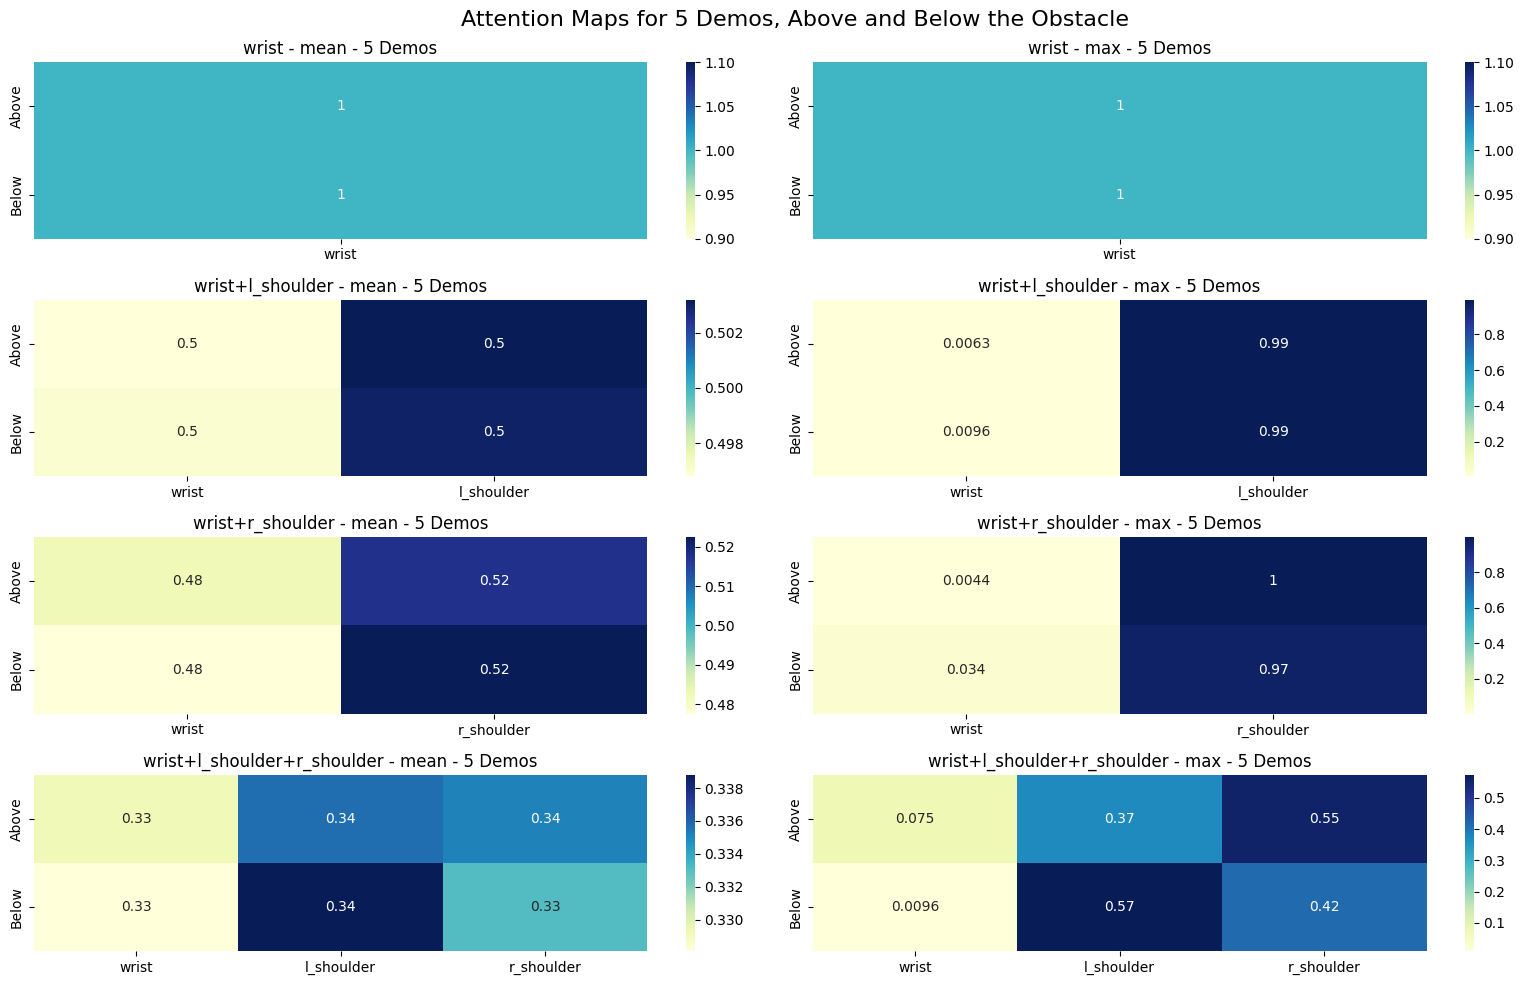

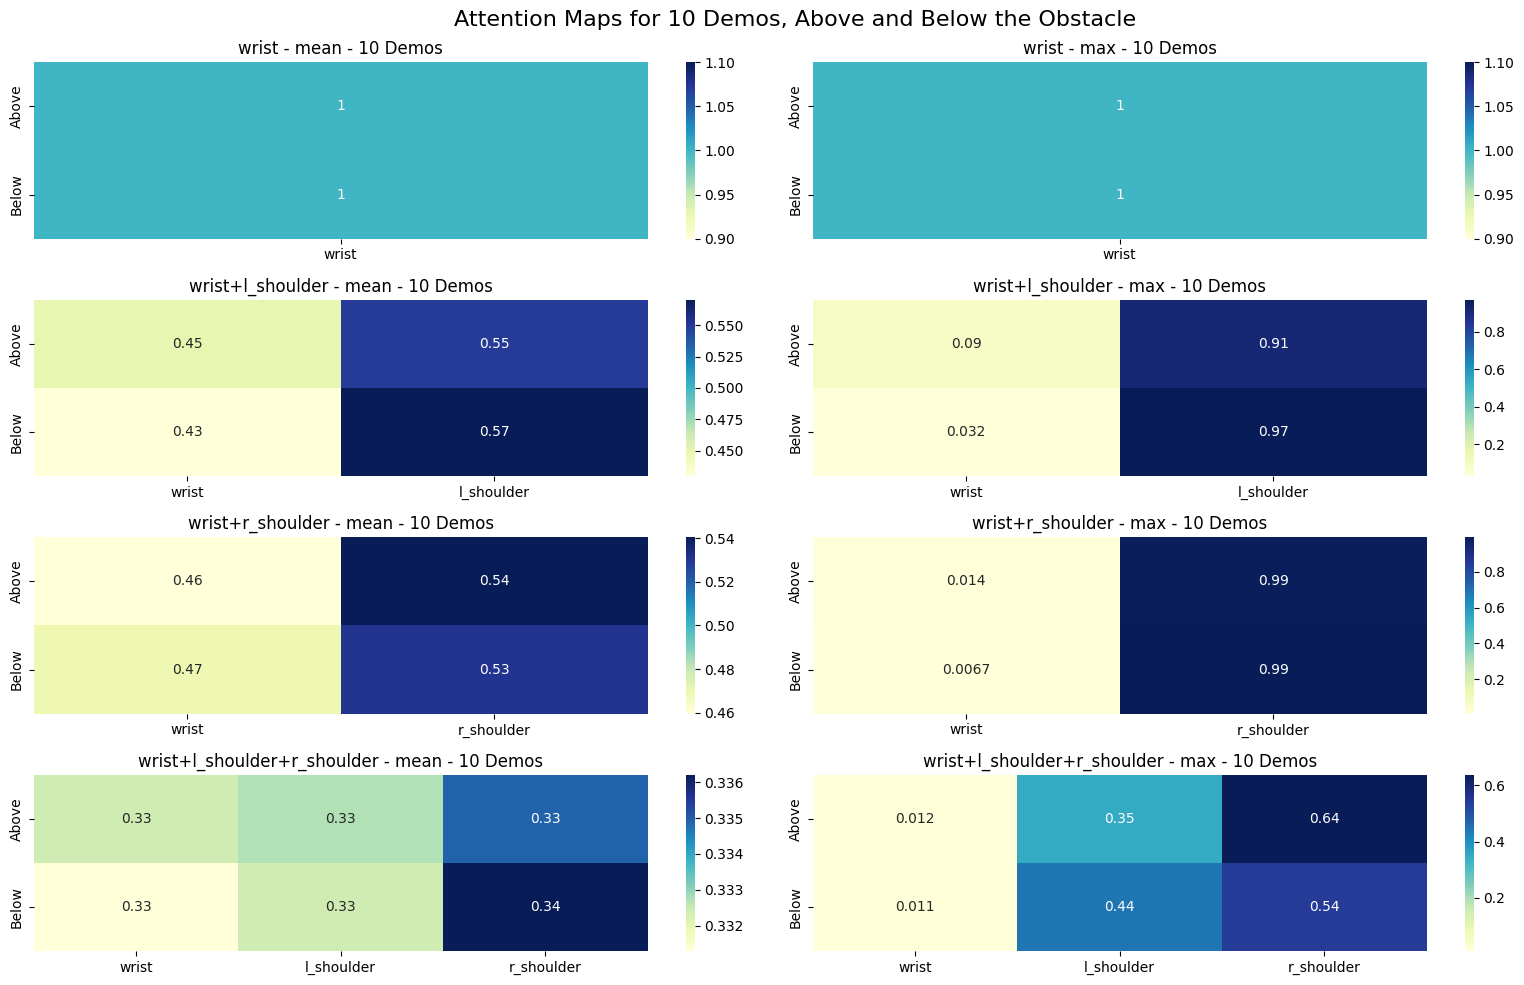

In [94]:
plot_cam_attention_heatmap(df, fix_tensors=True)

## Cam Attention Checks with different cameras - 2nd Time (shuffled training)
This now includes the `"shuffle_data": True` in the training, I think randomised training does help the network

### Multi-CNN Attention
Same as above but trained with the randomisation.

I didn't include the 1 demo here, so the graph is slightly shifted down and right, the scales are pretty much the same otherwise


In [95]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-multicnn-shuffled-training.csv")

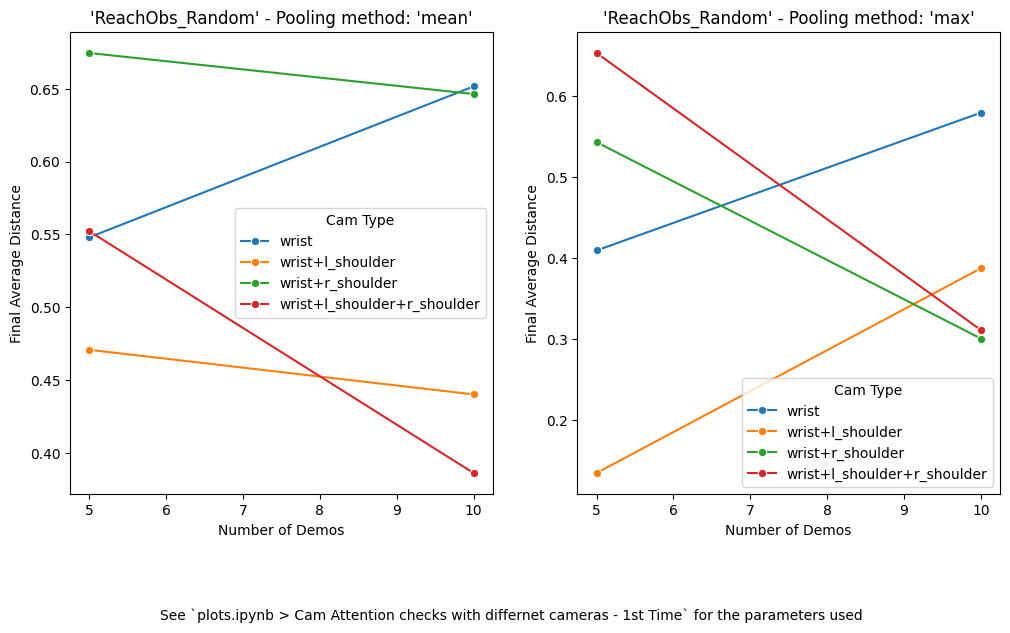

In [96]:
plot_cam_attention(df, "ReachObs_Random")

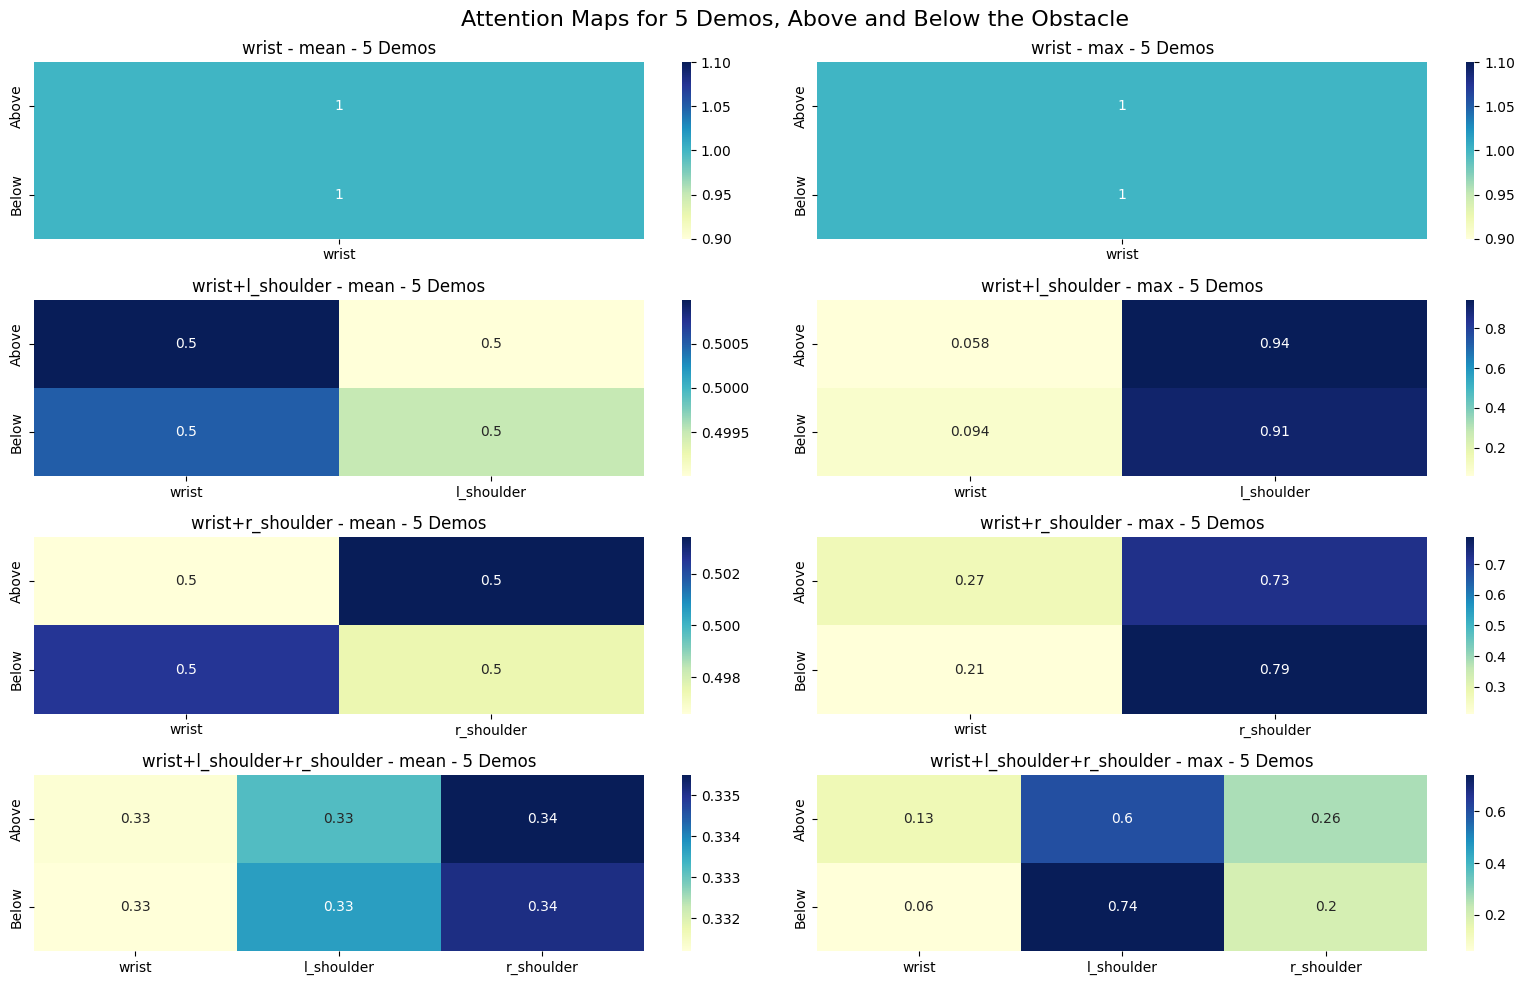

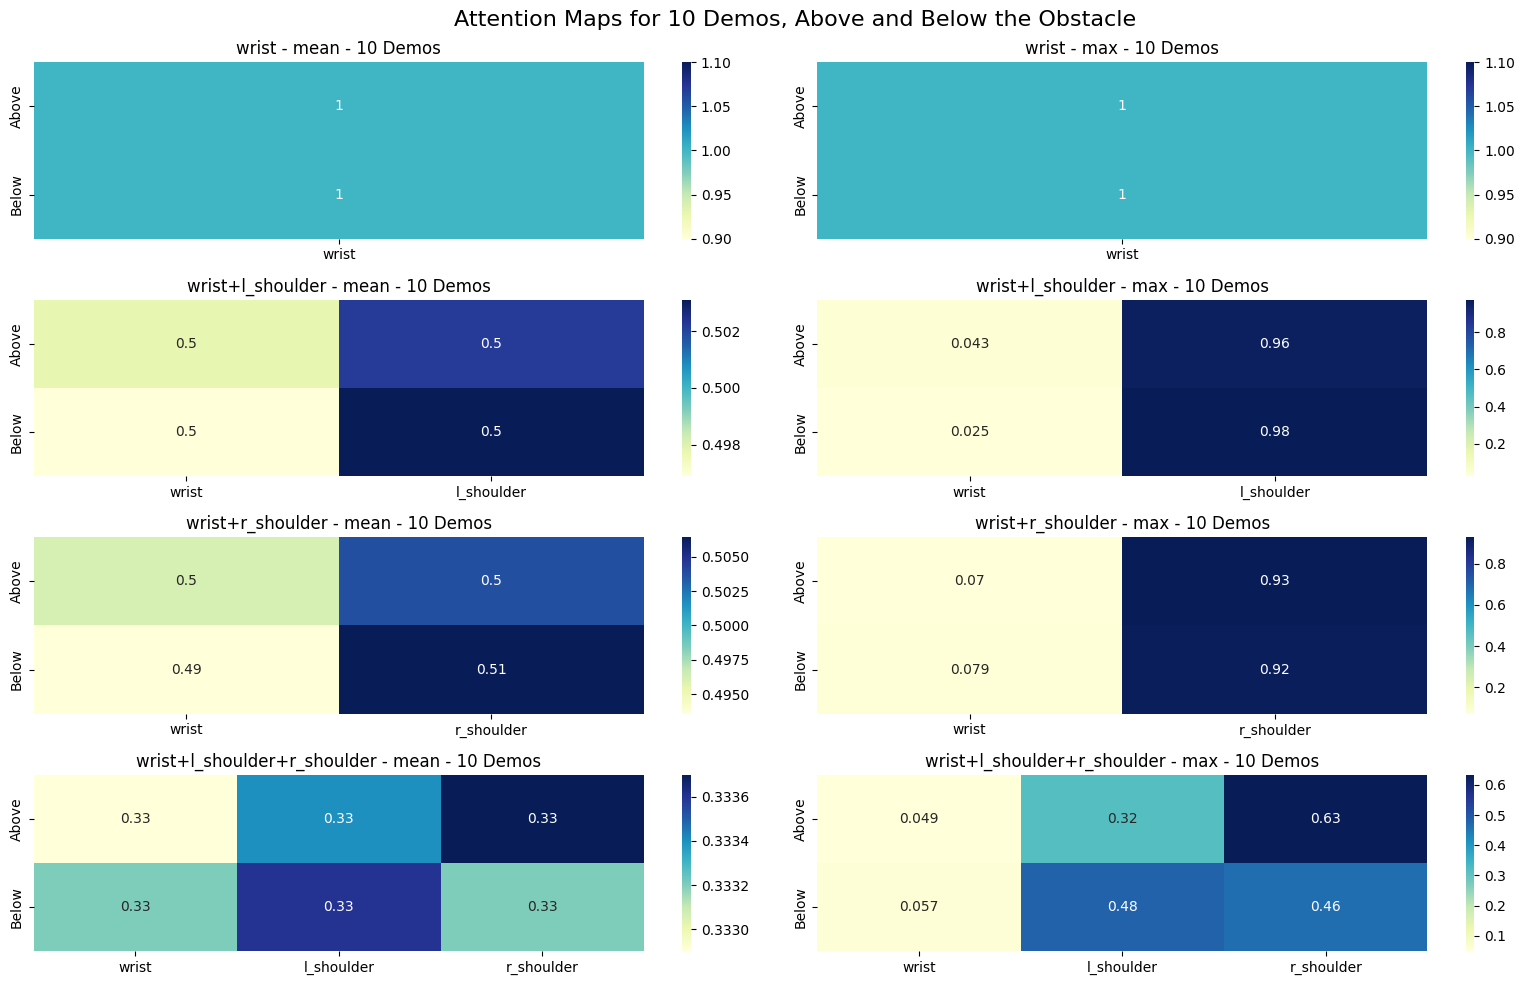

In [97]:
plot_cam_attention_heatmap(df, fix_tensors=True)

### Single-CNN Attention
This performs a lot better with shuffled data I think it is generalising better?

//TODO: Add these in the report before moving onto the ViT?

In [98]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-singlecnn-shuffled-training.csv")


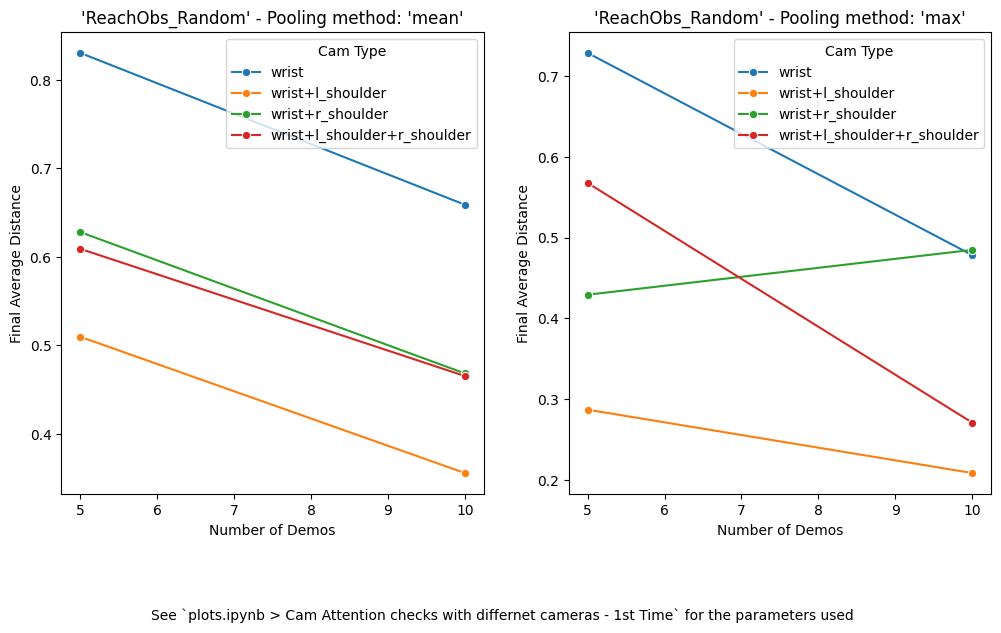

In [99]:
plot_cam_attention(df, "ReachObs_Random")

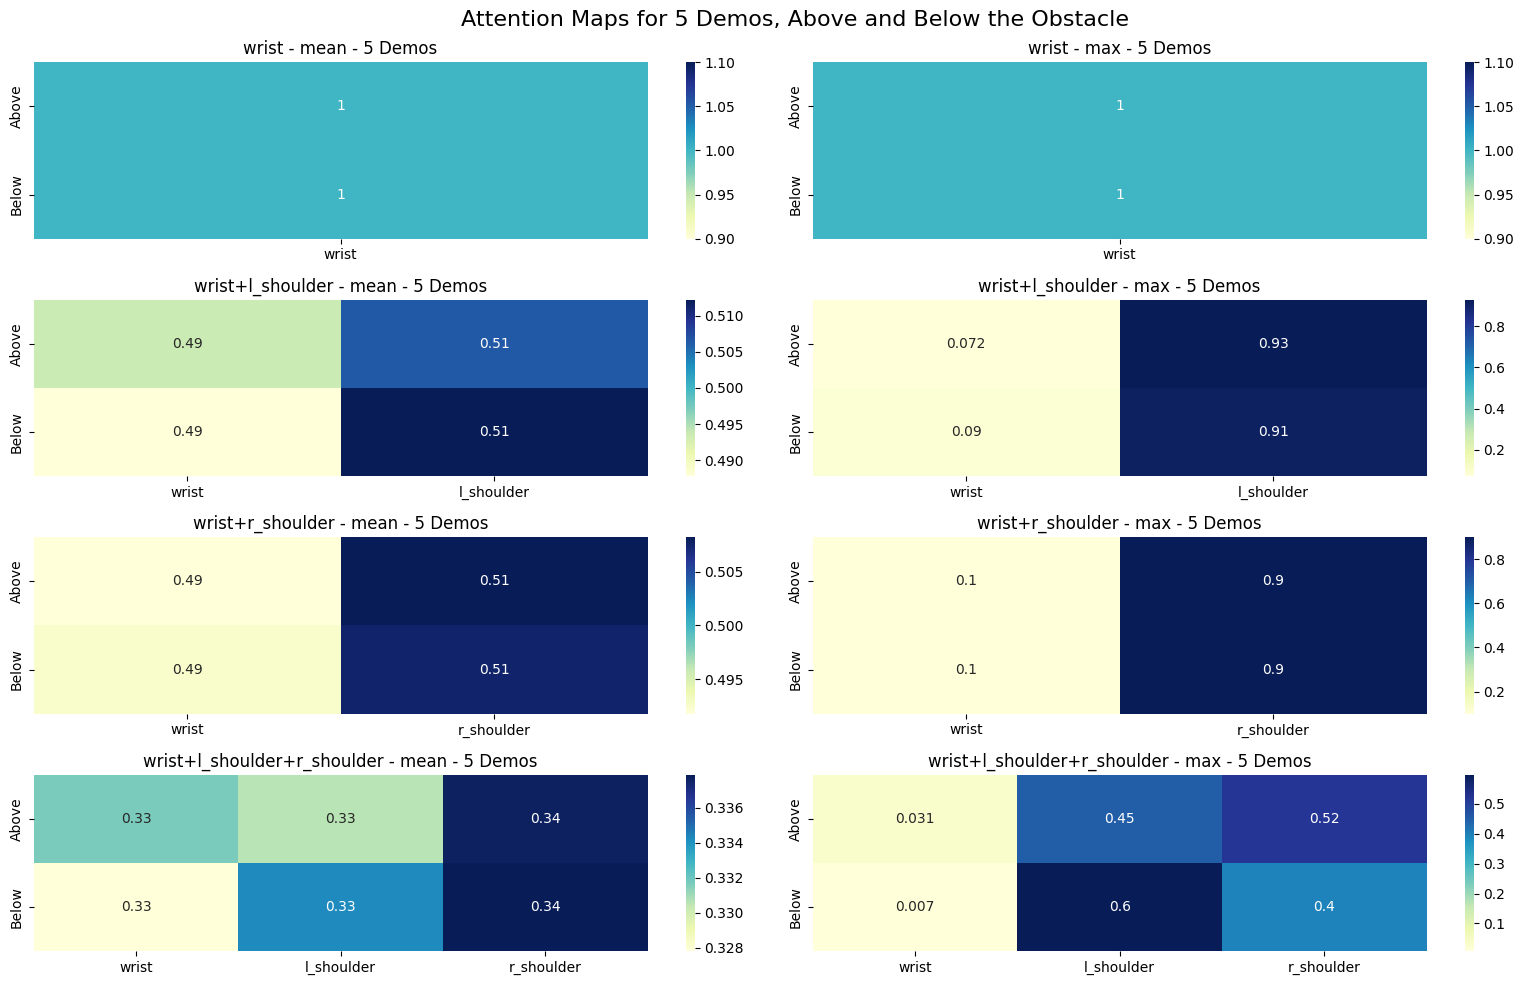

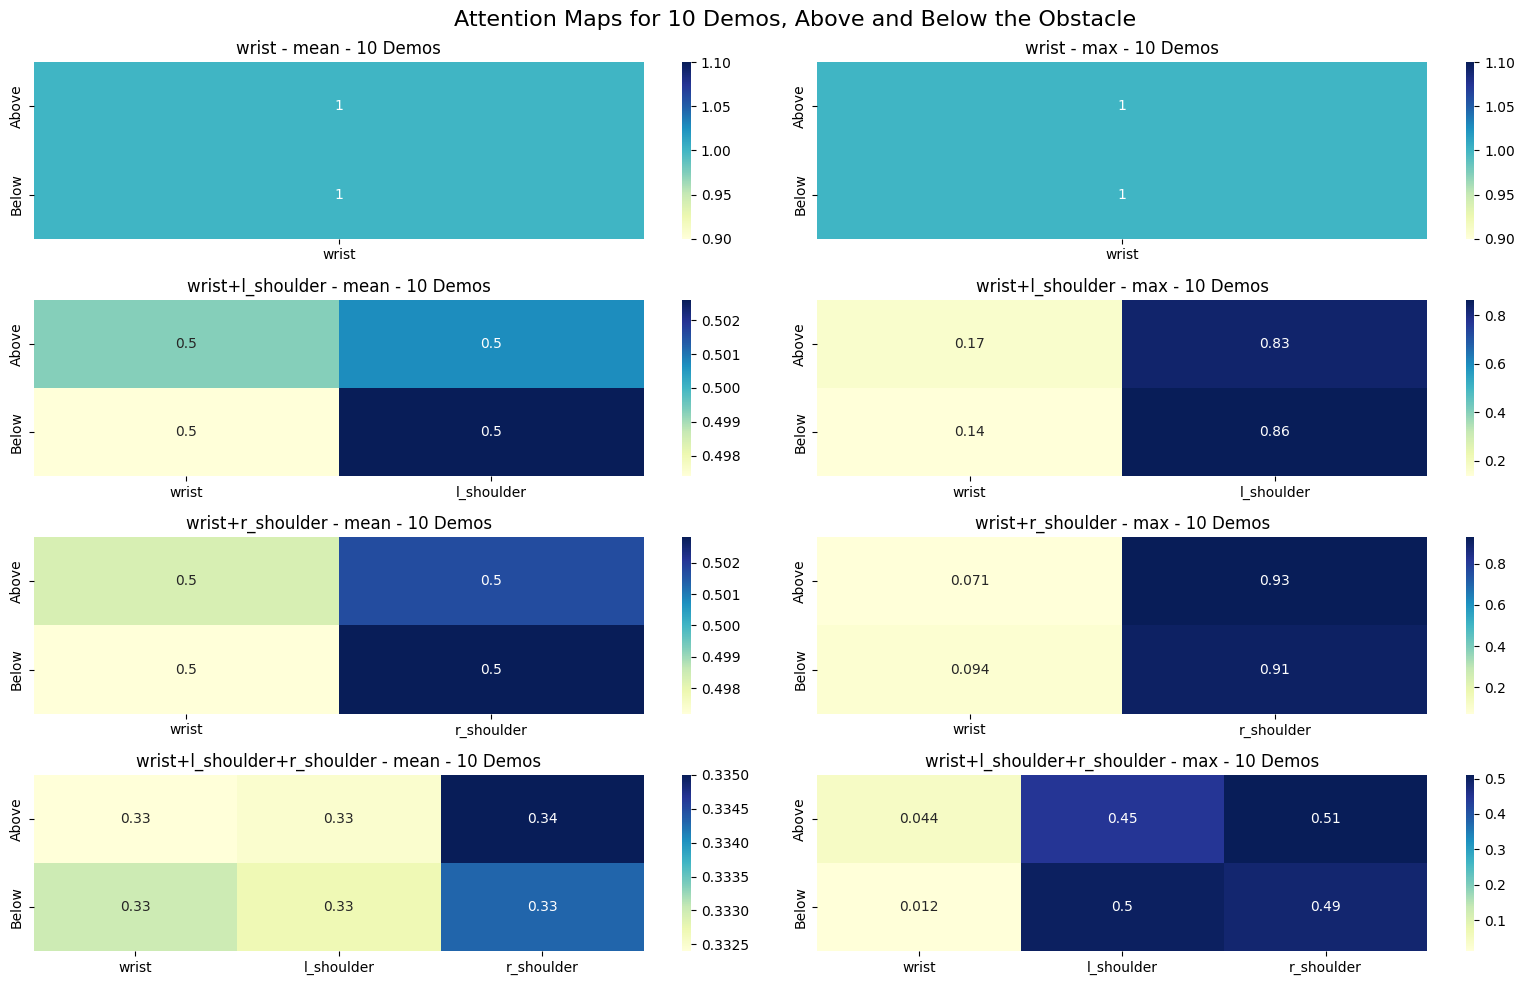

In [100]:
plot_cam_attention_heatmap(df, fix_tensors=True)


# Vision Experiments 


## Static Simple Grasp - Checking which cams work best
data is created using randomisation of training and 20 repeats.


In [11]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-results.csv")

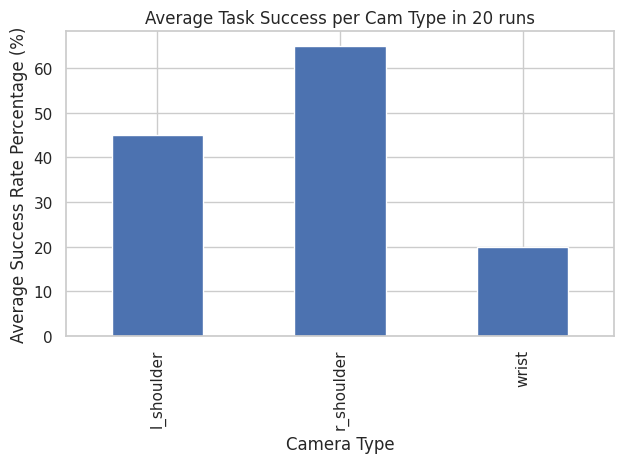

In [15]:
# Group by cam_type and compute average success
avg_success = df.groupby('cam_type')['is_success'].mean() * 100 ## %
# Plot
avg_success.plot(kind='bar', ylabel='Average Success Rate Percentage (%)', title='Average Task Success per Cam Type in 20 runs')
plt.xlabel('Camera Type')
plt.tight_layout()
plt.show()


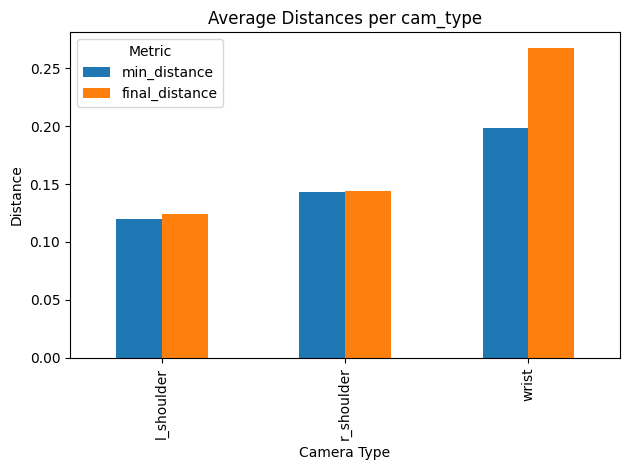

In [10]:
avg_distances = df.groupby('cam_type')[['min_distance', 'final_distance']].mean()

# Plot
avg_distances.plot(kind='bar', title='Average Distances per cam_type')
plt.ylabel('Distance')
plt.xlabel('Camera Type')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The `wrist` camera was allowed longer `'max_eplen'` this is because the network would not do well with only `'demo_max'`, therefore its final distance is usally further away because it is forced to move for longer and without the ability to complete the task it just explores out-of-distribution areaas of the workspace
